In [2]:
import time

import numpy as np

from scipy import special, integrate, spatial

import sympy
from sympy.printing.numpy import SciPyPrinter

from astropy import units as u

In [3]:
from matplotlib import pyplot as plt 

Helper functions from [circular_sersic_with_green_integral.ipynb](circular_sersic_with_green_integral.ipynb)

In [4]:
BN_ICOEFFS = [2, -1/3, 4/405, 46/25515, 131/1148175, -2194697/30690717750]

def f_bn(n):
    """
    Ciotti and Bertin 99, valid for n >~ 0.36
    """
    return np.sum([C*n**(1-i) for i, C in enumerate(BN_ICOEFFS)], axis=0)

def sersic_profile(R, Ie, Re, n):
    bn = f_bn(n)
    return Ie * np.exp(-bn*((R/Re)**(1/n)-1))

def log_sersic_profile(R, Ie, Re, n):
    bn = f_bn(n)
    return np.log(Ie) - bn*((R/Re)**(1/n)-1)

In [14]:
def sersic_distribution(U, Re, n, Router=np.inf):
    bn = f_bn(n)

    Iemax = 1/finteg(Router, Re, n, bn, 1)

    sympy_gamma = U*bn**(2*n)*np.exp(-bn)/(Iemax*Re**2*n)
    gamma_arg = special.gammaincinv(2*n, sympy_gamma / special.gamma(2*n))
    return Re*(gamma_arg/bn)**n


In [9]:
def sersic_plus_uniform_circle(ntotal, fbkg, n, Re=1, Router=10, polar_out=True):
    nbkg = int(ntotal*fbkg)
    nfg = ntotal - nbkg

    r_bkg = np.sqrt(np.random.rand(nbkg))*Router
    θ_bkg = np.random.rand(nbkg)*2*np.pi

    r_fg = sersic_distribution(np.random.rand(nfg), Re, n, Router)
    θ_fg = np.random.rand(nfg)*2*np.pi

    r, θ = np.concatenate([r_fg, r_bkg]), np.concatenate([θ_fg, θ_bkg])

    if polar_out:
        return r, θ, nfg
    else:
        x = r*np.cos(θ)
        y = r*np.sin(θ)
        return x, y, nfg


In [19]:
def dimensionless_path_integrand(x, y, Δx, Δy, Re, n):
    bn = f_bn(n)
    Rsq = x*x + y*y
    twon = 2*n
    segments = Re**2*bn**(-twon)*n*(x*Δy - y*Δx)*np.exp(bn)*special.gamma(twon)*special.gammainc(twon, Re**(-1/n)*bn*Rsq**(1/twon))/Rsq
    return np.sum(segments)

def sersic_integrate_hull(hull, n_per_segment, n, Re):
    vertxys = hull.points[hull.vertices].T
    edgexys = np.linspace(vertxys, np.roll(vertxys,-1, axis=-1), n_per_segment).T
    integral_of_segments = [dimensionless_path_integrand(x, y, x[1]-x[0], y[1]-y[0], Re=Re, n=n) for x,y in edgexys]
    return np.sum(integral_of_segments)

In [27]:
def finteg(x, Re, n, bn, Ie):
    return Ie*Re**2*bn**(-2*n)*n*np.exp(bn)*special.gamma(2*n)*special.gammainc(2*n, Re**(-1/n)*bn*x**(n**(-1.0)))

# Infer glx properties w/ nautilus

In [20]:
from scipy import stats
import nautilus 
import corner

In [21]:
prior = nautilus.Prior()

prior.add_parameter('x0', (-2, 2))
prior.add_parameter('y0', (-2, 2))
prior.add_parameter('Re', (0.1, 2))
prior.add_parameter('n', (0.5, 4))
prior.add_parameter('fbkg', (0.1, 0.9))

In [22]:
def loglikes(param_dict, datahull, n_per_segment=1000):
    x0 = param_dict['x0']
    y0 = param_dict['y0']
    Re = param_dict['Re']
    n = param_dict['n']
    fbkg = param_dict['fbkg']

    sersic_integral = sersic_integrate_hull(datahull, n_per_segment, n, Re)

    R = np.hypot(datahull.points[:,0] - x0, datahull.points[:,1] - y0)
    logfg = log_sersic_profile(R, Ie=1, Re=Re, n=n) - np.log(sersic_integral) + np.log(1 - fbkg)

    logbg = np.log(fbkg) -  np.log(datahull.area)

    return np.logaddexp(logfg, logbg)

def loglike(*args, **kwargs):
    return np.sum(loglikes(*args, **kwargs))

In [28]:
x, y, nfg = sersic_plus_uniform_circle(1000, .5, 2, Re=1, polar_out=False)

In [29]:
datahull = spatial.ConvexHull(np.array((x, y)).T)

sampler = nautilus.Sampler(prior, loglike, n_live=1000, likelihood_kwargs=dict(datahull=datahull, n_per_segment=1000))
t_start = time.time()
sampler.run(verbose=True)
t_end = time.time()
print('Total time: {:.1f}s'.format(t_end - t_start))

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 28     | 1        | 4        | 32900    | N/A    | 10071 | -3856.00 
Total time: 116.9s


In [111]:
datahull = spatial.ConvexHull(np.array((x, y)).T)

sampler = nautilus.Sampler(prior, loglike, n_live=1000, likelihood_kwargs=dict(datahull=datahull, n_per_segment=1000), pool=2)
t_start = time.time()
sampler.run(verbose=True)
t_end = time.time()
print('Total time: {:.1f}s'.format(t_end - t_start))

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 29     | 1        | 4        | 33400    | N/A    | 10056 | -3794.52 
Total time: 76.3s


In [112]:
datahull = spatial.ConvexHull(np.array((x, y)).T)

sampler = nautilus.Sampler(prior, loglike, n_live=1000, likelihood_kwargs=dict(datahull=datahull, n_per_segment=1000), pool=4)
t_start = time.time()
sampler.run(verbose=True)
t_end = time.time()
print('Total time: {:.1f}s'.format(t_end - t_start))

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 29     | 1        | 4        | 33700    | N/A    | 10094 | -3794.51 
Total time: 50.7s


In [113]:
datahull = spatial.ConvexHull(np.array((x, y)).T)

sampler = nautilus.Sampler(prior, loglike, n_live=1000, likelihood_kwargs=dict(datahull=datahull, n_per_segment=1000), pool=8)
t_start = time.time()
sampler.run(verbose=True)
t_end = time.time()
print('Total time: {:.1f}s'.format(t_end - t_start))

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 30     | 1        | 4        | 33384    | N/A    | 10112 | -3794.54 
Total time: 40.6s


In [114]:
datahull = spatial.ConvexHull(np.array((x, y)).T)

sampler = nautilus.Sampler(prior, loglike, n_live=1000, likelihood_kwargs=dict(datahull=datahull, n_per_segment=1000), pool=12)
t_start = time.time()
sampler.run(verbose=True)
t_end = time.time()
print('Total time: {:.1f}s'.format(t_end - t_start))

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 29     | 1        | 4        | 33372    | N/A    | 10029 | -3794.52 
Total time: 38.3s


In [116]:
datahull = spatial.ConvexHull(np.array((x, y)).T)

sampler = nautilus.Sampler(prior, loglike, n_live=1000, likelihood_kwargs=dict(datahull=datahull, n_per_segment=1000), pool=16)
t_start = time.time()
sampler.run(verbose=True)
t_end = time.time()
print('Total time: {:.1f}s'.format(t_end - t_start))

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 30     | 1        | 4        | 33600    | N/A    | 10104 | -3794.53 
Total time: 38.4s


In [118]:
datahull = spatial.ConvexHull(np.array((x, y)).T)

sampler = nautilus.Sampler(prior, loglike, n_live=1000, likelihood_kwargs=dict(datahull=datahull, n_per_segment=1000), pool=20)
t_start = time.time()
sampler.run(verbose=True)
t_end = time.time()
print('Total time: {:.1f}s'.format(t_end - t_start))

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 29     | 1        | 4        | 33900    | N/A    | 10082 | -3794.53 
Total time: 39.3s


(this was run on a 16 core machine.  Increasing beyond 16 just makes things flat or worse)

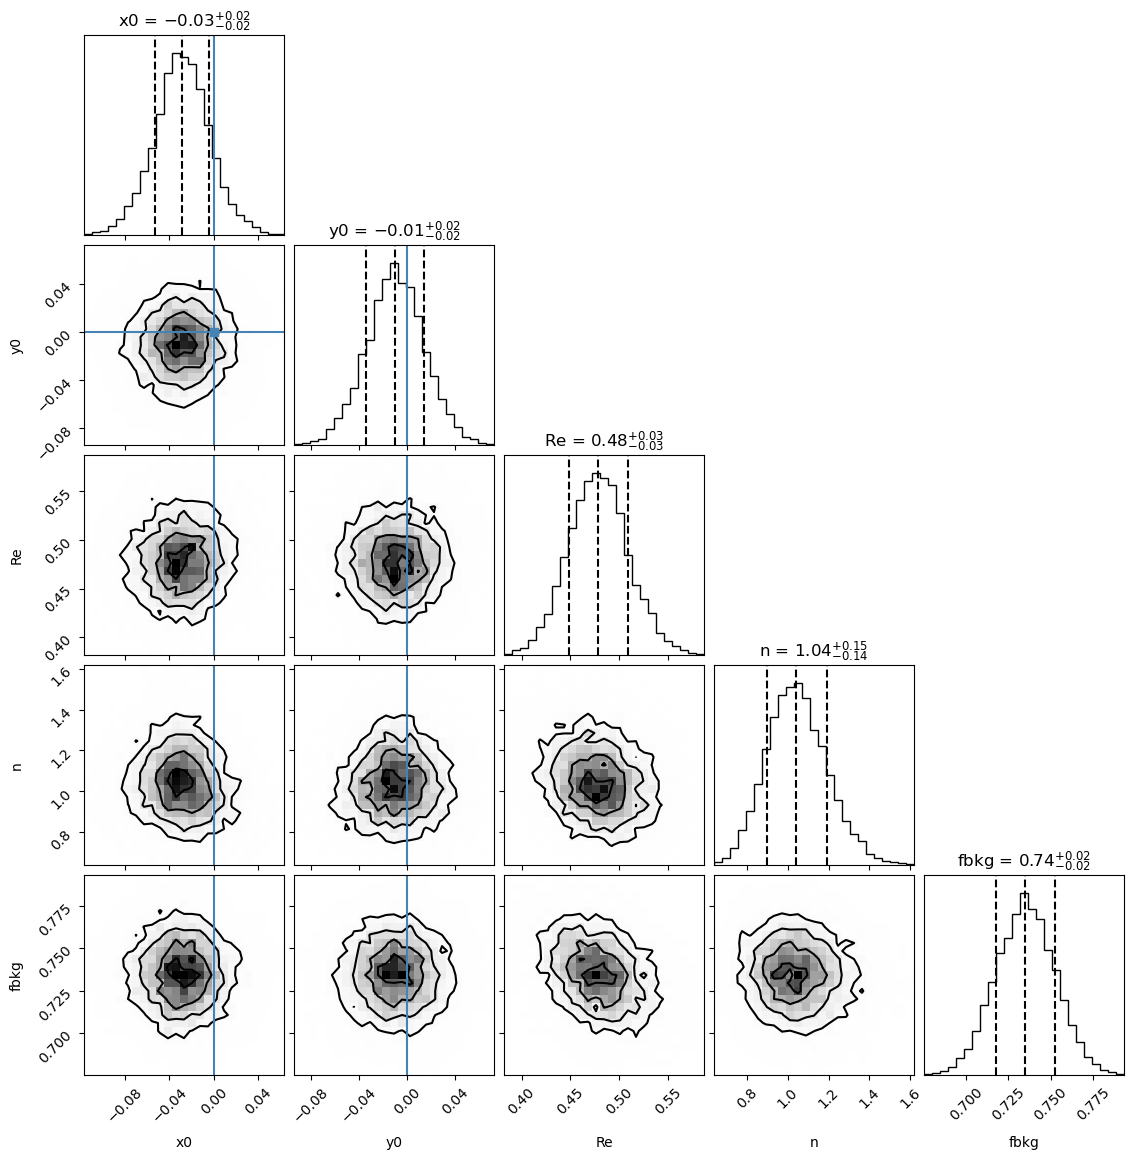

In [117]:
points, log_w, log_l = sampler.posterior()
corner.corner(
    points, weights=np.exp(log_w), bins=25, labels=prior.keys,
    plot_datapoints=False, range=np.repeat(0.999, len(prior.keys)), 
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    truths=[0, 0, 1, 2, .5]);

Well that doesn't seem right.  Lets try inspecting the results more closely:

np.float64(-3778.073710454939)

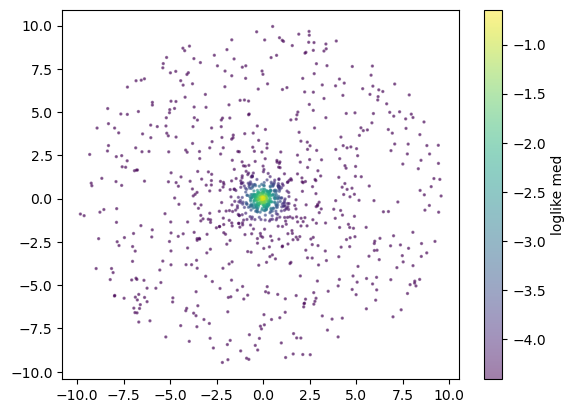

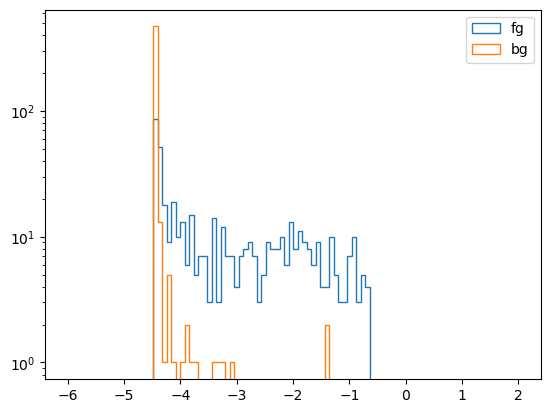

In [133]:
lls_med = loglikes(dict(x0=-0.03,y0=0.01,Re=0.48,n=1.04,fbkg=.74), datahull)

plt.scatter(*datahull.points.T, c=lls_med, s=2, alpha=.5)
plt.colorbar().set_label('loglike med')

plt.figure()
plt.hist(lls_med[:nfg], 100, log=True, range=(-6, 2), histtype='step', label='fg')
plt.hist(lls_med[nfg:], 100, log=True, range=(-6, 2), histtype='step', label='bg')
plt.legend(loc=0)
np.sum(lls_med)

np.float64(-3898.901105425806)

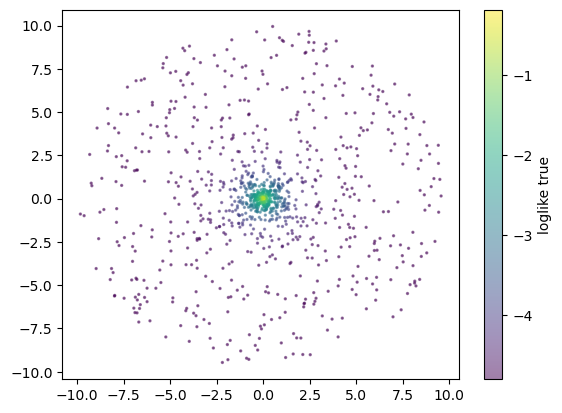

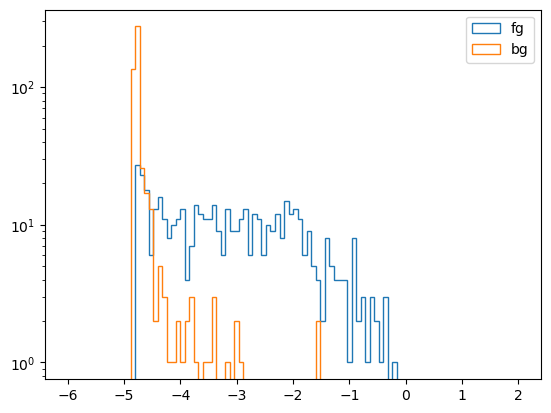

In [134]:
lls_true = loglikes(dict(x0=0,y0=0,Re=1,n=2,fbkg=.5), datahull)

plt.scatter(*datahull.points.T, c=lls_true, s=2, alpha=.5)
plt.colorbar().set_label('loglike true')

plt.figure()
plt.hist(lls_true[:nfg], 100, log=True, range=(-6, 2), histtype='step', label='fg')
plt.hist(lls_true[nfg:], 100, log=True, range=(-6, 2), histtype='step', label='bg')
plt.legend(loc=0)
np.sum(lls_true)

/tmp/ipykernel_4549/4156455646.py:13: RuntimeWarning: divide by zero encountered in log
  logbg = np.log(fbkg) -  np.log(datahull.area)


np.float64(-12600.41515977245)

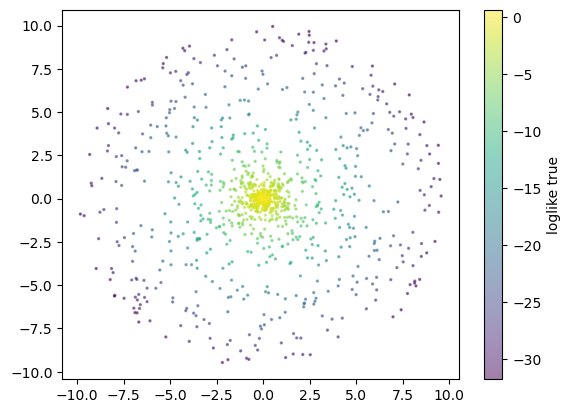

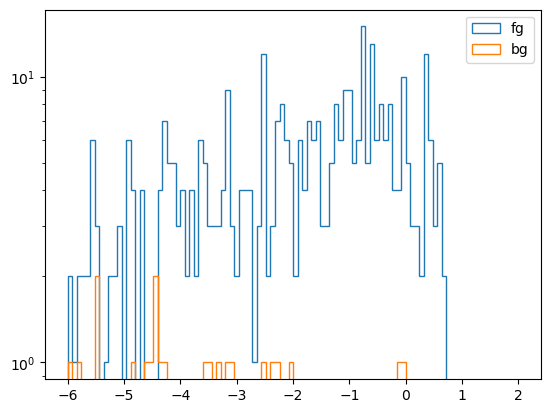

In [135]:
lls_allfg = loglikes(dict(x0=-0.03,y0=0.01,Re=0.48,n=1.04,fbkg=0), datahull)

plt.scatter(*datahull.points.T, c=lls_allfg, s=2, alpha=.5)
plt.colorbar().set_label('loglike true')

plt.figure()
plt.hist(lls_allfg[:nfg], 100, log=True, range=(-6, 2), histtype='step', label='fg')
plt.hist(lls_allfg[nfg:], 100, log=True, range=(-6, 2), histtype='step', label='bg')
plt.legend(loc=0)
np.sum(lls_allfg)

/tmp/ipykernel_4549/4156455646.py:11: RuntimeWarning: divide by zero encountered in log
  logfg = log_sersic_profile(R, Ie=1, Re=Re, n=n) - np.log(sersic_integral) + np.log(1 - fbkg)


(np.float64(-4110.183341351258), np.float64(-4.110183341351256))

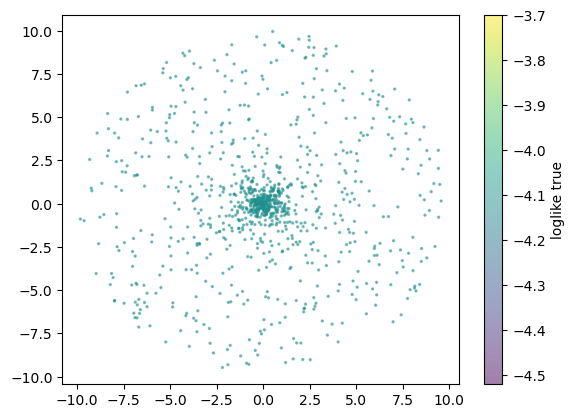

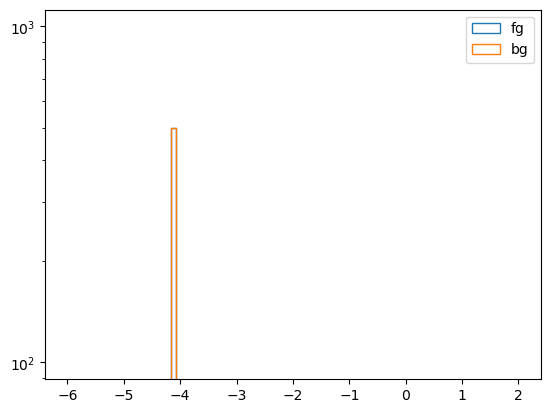

In [136]:
lls_allbg = loglikes(dict(x0=-0.03,y0=0.01,Re=0.48,n=1.04,fbkg=1), datahull)


plt.scatter(*datahull.points.T, c=lls_allbg, s=2, alpha=.5)
plt.colorbar().set_label('loglike true')

plt.figure()
plt.hist(lls_allbg[:nfg], 100, log=True, range=(-6, 2), histtype='step', label='fg')
plt.hist(lls_allbg[nfg:], 100, log=True, range=(-6, 2), histtype='step', label='bg')
plt.legend(loc=0)
np.sum(lls_allbg), lls_allbg[0]

/tmp/ipykernel_4549/4156455646.py:13: RuntimeWarning: divide by zero encountered in log
  logbg = np.log(fbkg) -  np.log(datahull.area)


np.float64(-5683.5409957453985)

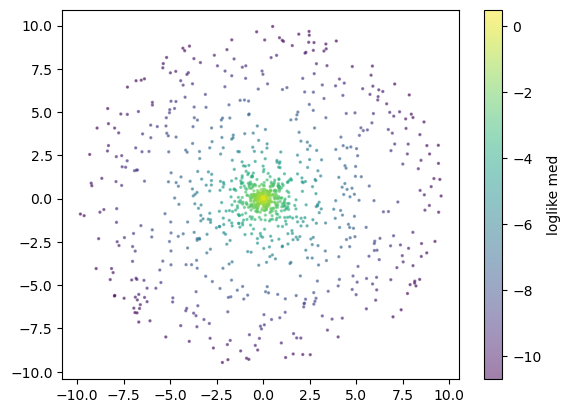

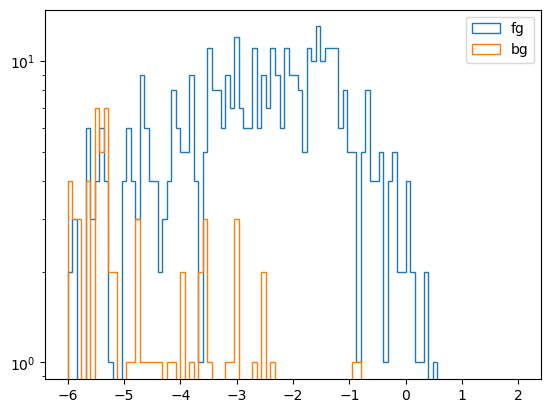

In [123]:
lls_test = loglikes(dict(x0=0.0,y0=0.0,Re=1,n=2,fbkg=0), datahull)

plt.scatter(*datahull.points.T, c=lls_test, s=2, alpha=.5)
plt.colorbar().set_label('loglike med')

plt.figure()
plt.hist(lls_test[:nfg], 100, log=True, range=(-6, 2), histtype='step', label='fg')
plt.hist(lls_test[nfg:], 100, log=True, range=(-6, 2), histtype='step', label='bg')
plt.legend(loc=0)
np.sum(lls_test)

And examine the behavior near the correct answer

Text(0.5, 0, 'n')

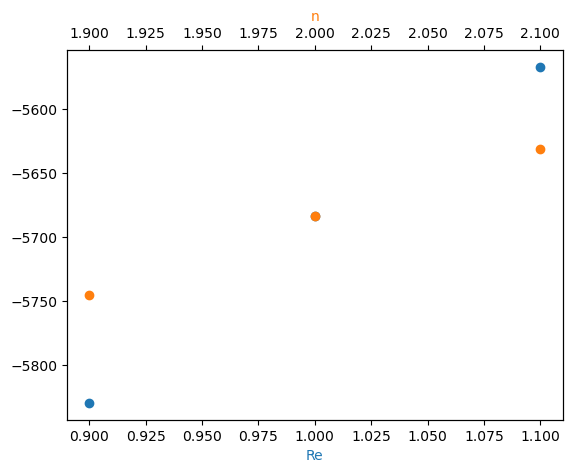

In [137]:
params1 = [
    dict(x0=0.0,y0=0.0,Re=1,n=2,fbkg=1e-10),
    dict(x0=0.0,y0=0.0,Re=1.1,n=2,fbkg=1e-10),
    dict(x0=0.0,y0=0.0,Re=0.9,n=2,fbkg=1e-10),
]

lls1 = [loglikes(d, datahull) for d in params1]

plt.scatter([p['Re'] for p in params1], [np.sum(ll) for ll in lls1], c='C0')
plt.xlabel('Re', c='C0')

params2 = [
    dict(x0=0.0,y0=0.0,Re=1,n=2,fbkg=1e-10),
    dict(x0=0.0,y0=0.0,Re=1,n=2.1,fbkg=1e-10),
    dict(x0=0.0,y0=0.0,Re=1,n=1.9,fbkg=1e-10),
]

lls2 = [loglikes(d, datahull) for d in params2]

plt.twiny()
plt.scatter([p['n'] for p in params2], [np.sum(ll) for ll in lls2], c='C1')
plt.xlabel('n', c='C1')

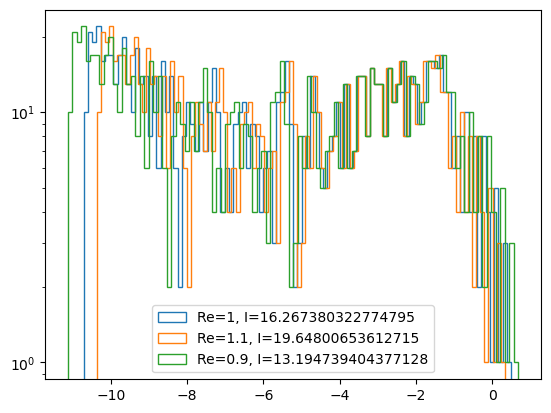

In [142]:
for i, ll in enumerate(lls1):
    integral = sersic_integrate_hull(datahull, n_per_segment=1000, n=params1[i]['n'], Re=params1[i]['Re'])
    plt.hist(ll, bins=100, histtype='step', label=f'Re={params1[i]['Re']}, I={integral}', log=True)
plt.legend(loc=0)

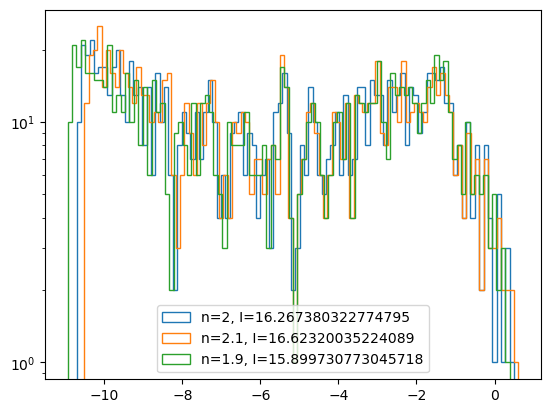

In [141]:
for i, ll in enumerate(lls2):
    integral = sersic_integrate_hull(datahull, n_per_segment=1000, n=params2[i]['n'], Re=params2[i]['Re'])
    plt.hist(ll, bins=100, histtype='step', label=f'n={params2[i]['n']}, I={integral}', log=True)
plt.legend(loc=0)

Variation with fbkg?

/tmp/ipykernel_4549/4156455646.py:13: RuntimeWarning: divide by zero encountered in log
  logbg = np.log(fbkg) -  np.log(datahull.area)
/tmp/ipykernel_4549/4156455646.py:11: RuntimeWarning: divide by zero encountered in log
  logfg = log_sersic_profile(R, Ie=1, Re=Re, n=n) - np.log(sersic_integral) + np.log(1 - fbkg)


Text(0.5, 0, 'fbkg')

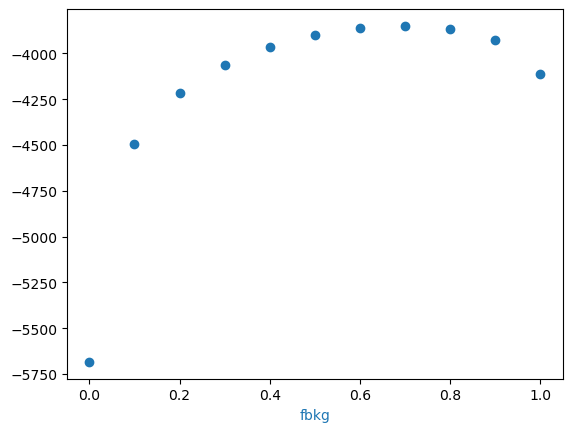

In [140]:
params = [
    dict(x0=0.0,y0=0.0,Re=1,n=2,fbkg=0),
    dict(x0=0.0,y0=0.0,Re=1,n=2,fbkg=.1),
    dict(x0=0.0,y0=0.0,Re=1,n=2,fbkg=.2),
    dict(x0=0.0,y0=0.0,Re=1,n=2,fbkg=.3),
    dict(x0=0.0,y0=0.0,Re=1,n=2,fbkg=.4),
    dict(x0=0.0,y0=0.0,Re=1,n=2,fbkg=.5),
    dict(x0=0.0,y0=0.0,Re=1,n=2,fbkg=.6),
    dict(x0=0.0,y0=0.0,Re=1,n=2,fbkg=.7),
    dict(x0=0.0,y0=0.0,Re=1,n=2,fbkg=.8),
    dict(x0=0.0,y0=0.0,Re=1,n=2,fbkg=.9),
    dict(x0=0.0,y0=0.0,Re=1,n=2,fbkg=1),
]

lls = [loglikes(d, datahull) for d in params]

plt.scatter([p['fbkg'] for p in params], [np.sum(ll) for ll in lls], c='C0')
plt.xlabel('fbkg', c='C0')


Force the fraction to be correct

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 25     | 1        | 4        | 29700    | N/A    | 10132 | -5305.15 
Total time: 34.1s


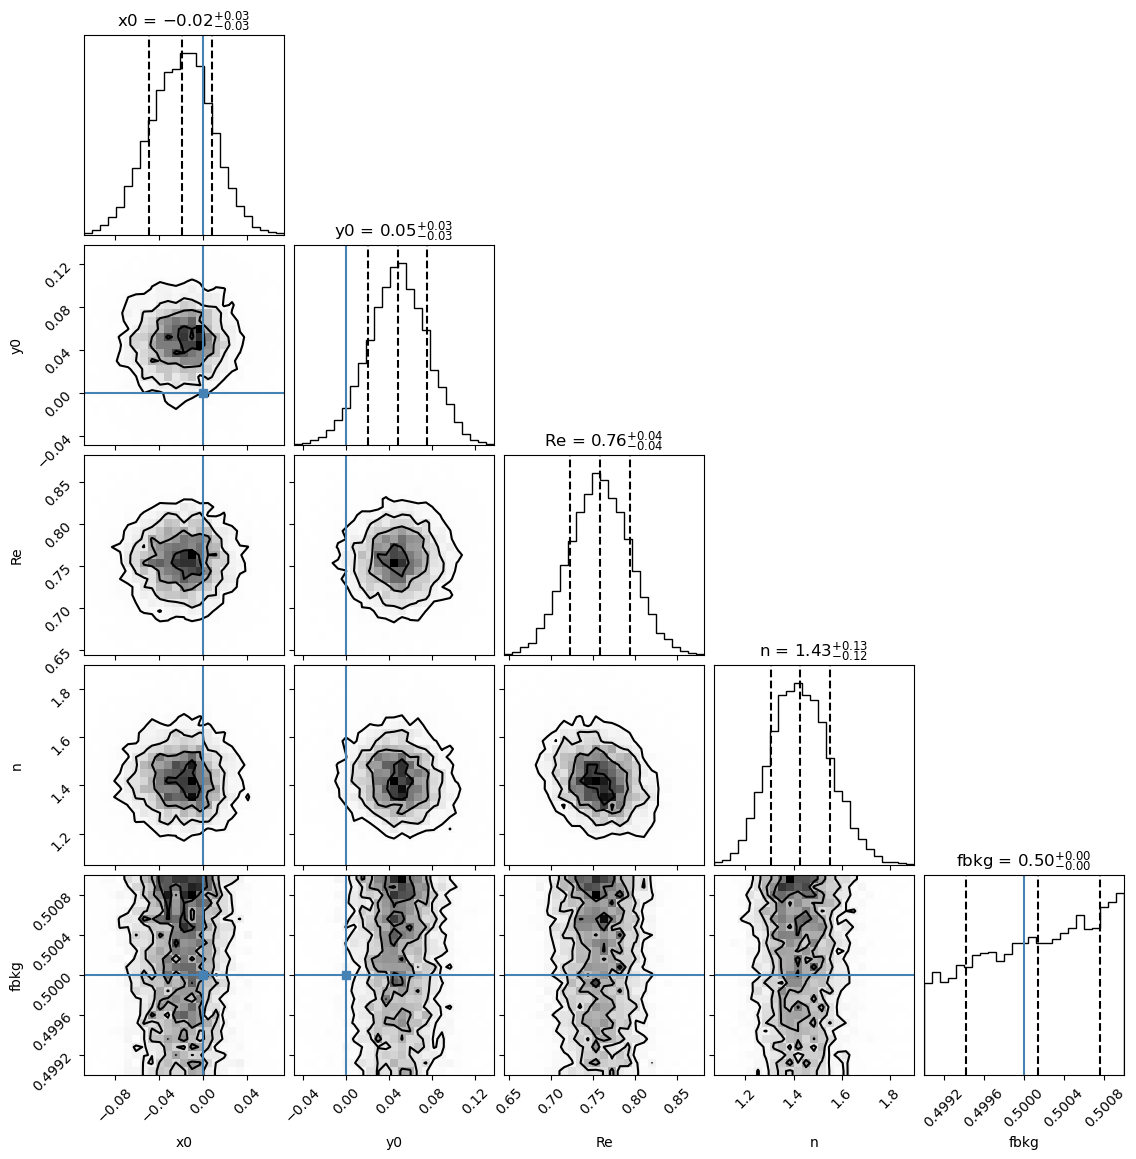

In [168]:
x, y, nfg = sersic_plus_uniform_circle(1000, fbkg=0.5, n=2, Re=1, polar_out=False, Router=100)
datahull = spatial.ConvexHull(np.array((x, y)).T)

prior2 = nautilus.Prior()

prior2.add_parameter('x0', (-2, 2))
prior2.add_parameter('y0', (-2, 2))
prior2.add_parameter('Re', (0.1, 2))
prior2.add_parameter('n', (0.5, 4))
prior2.add_parameter('fbkg', (0.499, 0.501))

sampler = nautilus.Sampler(prior2, loglike, n_live=1000, likelihood_kwargs=dict(datahull=datahull, n_per_segment=1000), pool=12)
t_start = time.time()
sampler.run(verbose=True)
t_end = time.time()
print('Total time: {:.1f}s'.format(t_end - t_start))

points, log_w, log_l = sampler.posterior()
corner.corner(
    points, weights=np.exp(log_w), bins=25, labels=prior.keys,
    plot_datapoints=False, range=np.repeat(0.999, len(prior.keys)), 
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    truths=[0, 0, 1, 2, 0.5]);

Even when forced in the correct fraction it's wrong??

## Experiments with various all-fg/all-bg

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 16     | 1        | 4        | 21168    | N/A    | 10115 | -4135.80 
Total time: 28.9s


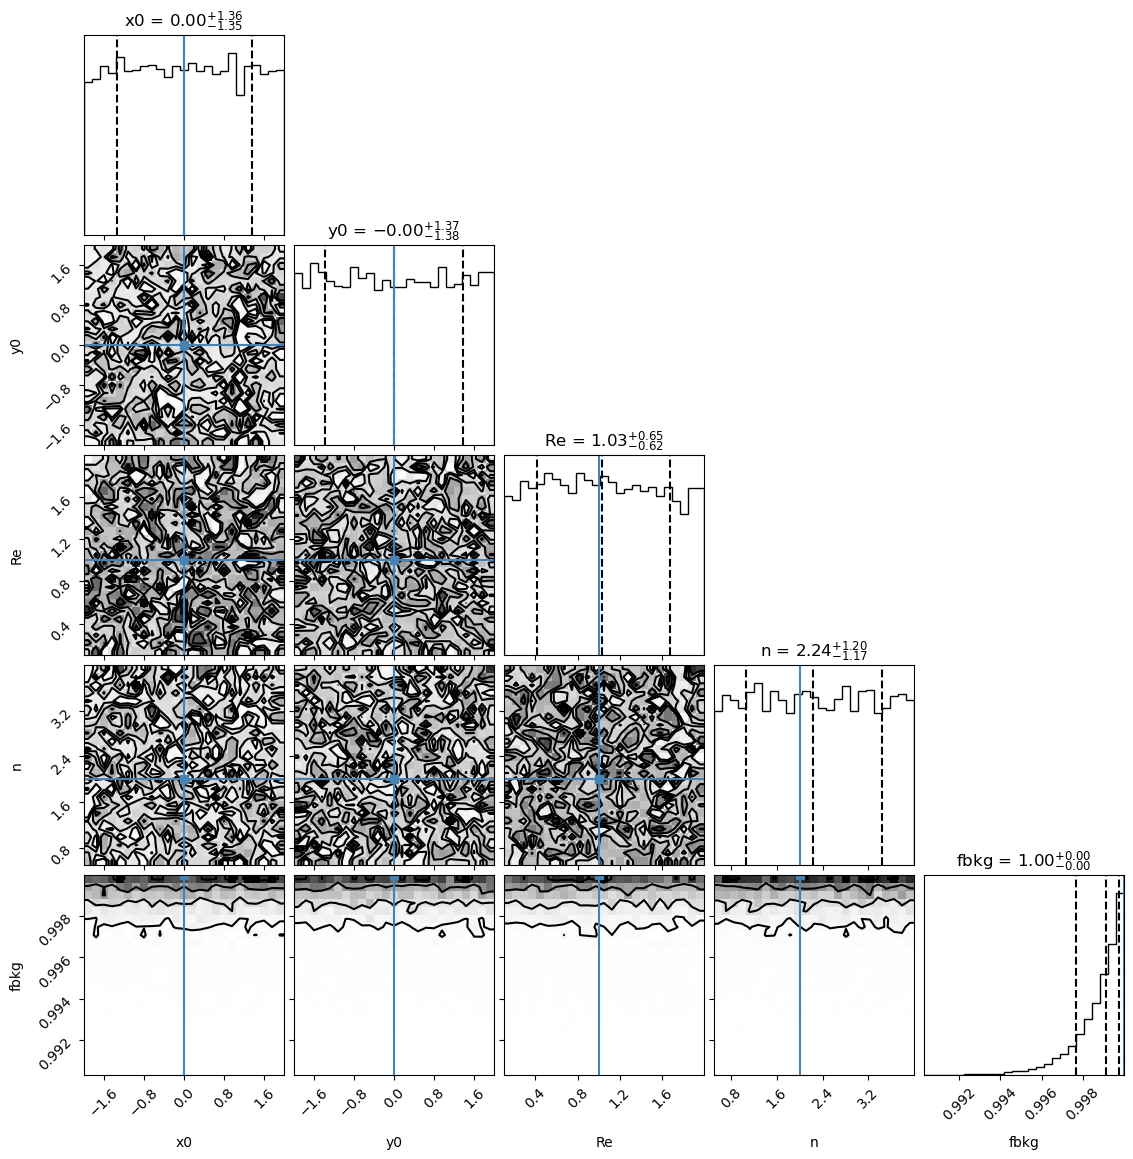

In [ ]:
x, y, nfg = sersic_plus_uniform_circle(1000, fbkg=1, n=2, Re=1, polar_out=False)
datahull = spatial.ConvexHull(np.array((x, y)).T)

prior2 = nautilus.Prior()

prior2.add_parameter('x0', (-2, 2))
prior2.add_parameter('y0', (-2, 2))
prior2.add_parameter('Re', (0.1, 2))
prior2.add_parameter('n', (0.5, 4))
prior2.add_parameter('fbkg', (0.0, 1.0))

sampler = nautilus.Sampler(prior2, loglike, n_live=1000, likelihood_kwargs=dict(datahull=datahull, n_per_segment=1000), pool=12)
t_start = time.time()
sampler.run(verbose=True)
t_end = time.time()
print('Total time: {:.1f}s'.format(t_end - t_start))

points, log_w, log_l = sampler.posterior()
corner.corner(
    points, weights=np.exp(log_w), bins=25, labels=prior.keys,
    plot_datapoints=False, range=np.repeat(0.999, len(prior.keys)), 
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    truths=[0, 0, 1, 2, 1]);

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 31     | 1        | 4        | 34884    | N/A    | 10016 | -2922.43 
Total time: 32.4s


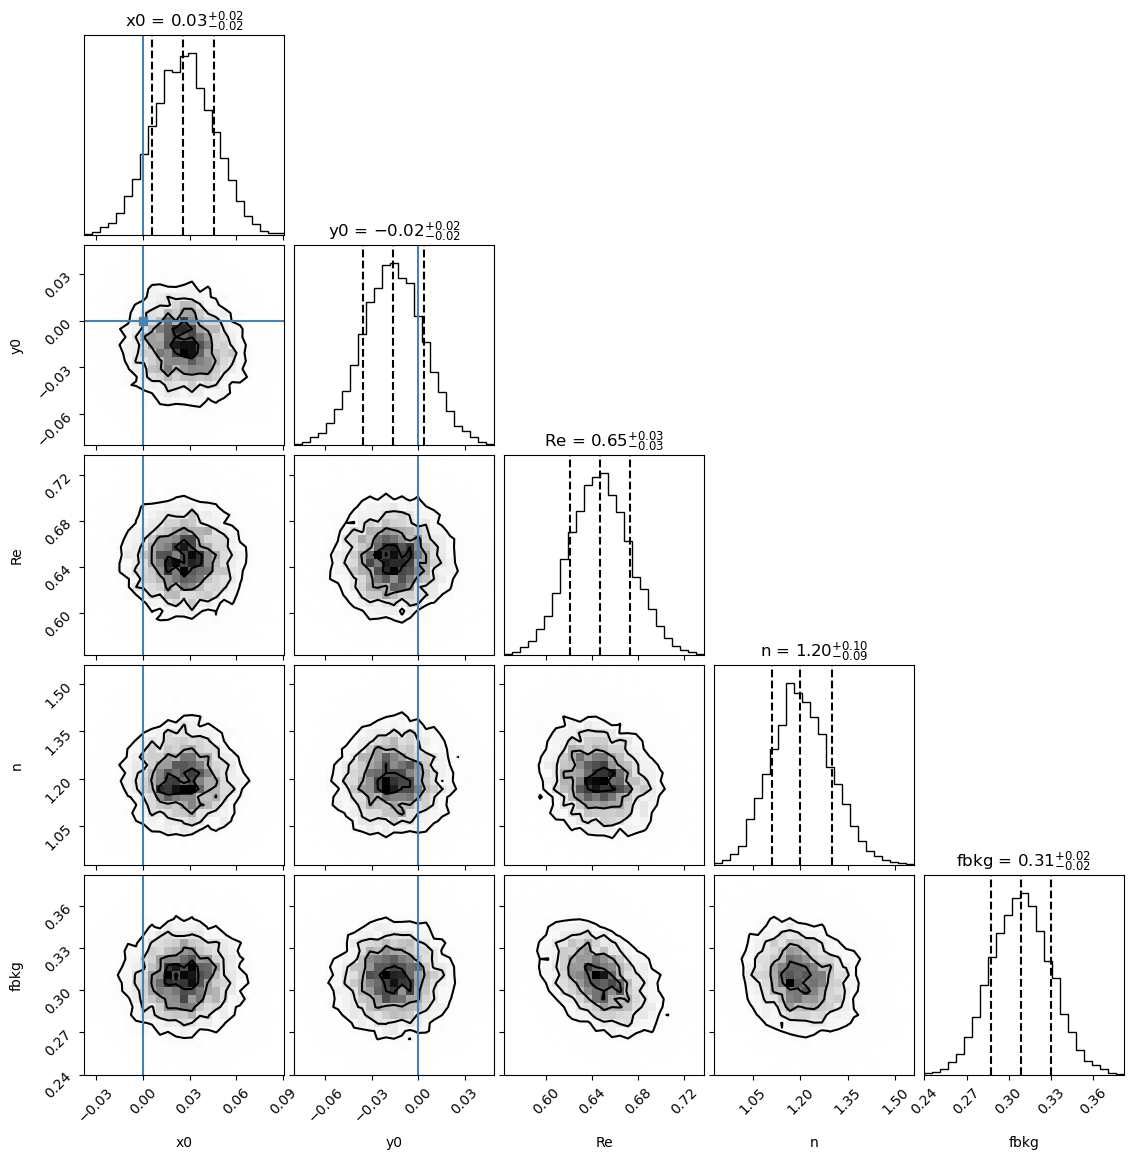

In [ ]:
x, y, nfg = sersic_plus_uniform_circle(1000, fbkg=0, n=2, Re=1, polar_out=False)
datahull = spatial.ConvexHull(np.array((x, y)).T)

prior2 = nautilus.Prior()

prior2.add_parameter('x0', (-2, 2))
prior2.add_parameter('y0', (-2, 2))
prior2.add_parameter('Re', (0.1, 2))
prior2.add_parameter('n', (0.5, 4))
prior2.add_parameter('fbkg', (0.0, 1.0))

sampler = nautilus.Sampler(prior2, loglike, n_live=1000, likelihood_kwargs=dict(datahull=datahull, n_per_segment=1000), pool=12)
t_start = time.time()
sampler.run(verbose=True)
t_end = time.time()
print('Total time: {:.1f}s'.format(t_end - t_start))

points, log_w, log_l = sampler.posterior()
corner.corner(
    points, weights=np.exp(log_w), bins=25, labels=prior.keys,
    plot_datapoints=False, range=np.repeat(0.999, len(prior.keys)), 
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    truths=[0, 0, 1, 2, 0]);

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 27     | 1        | 4        | 30780    | N/A    | 10021 | -3072.83 
Total time: 28.8s


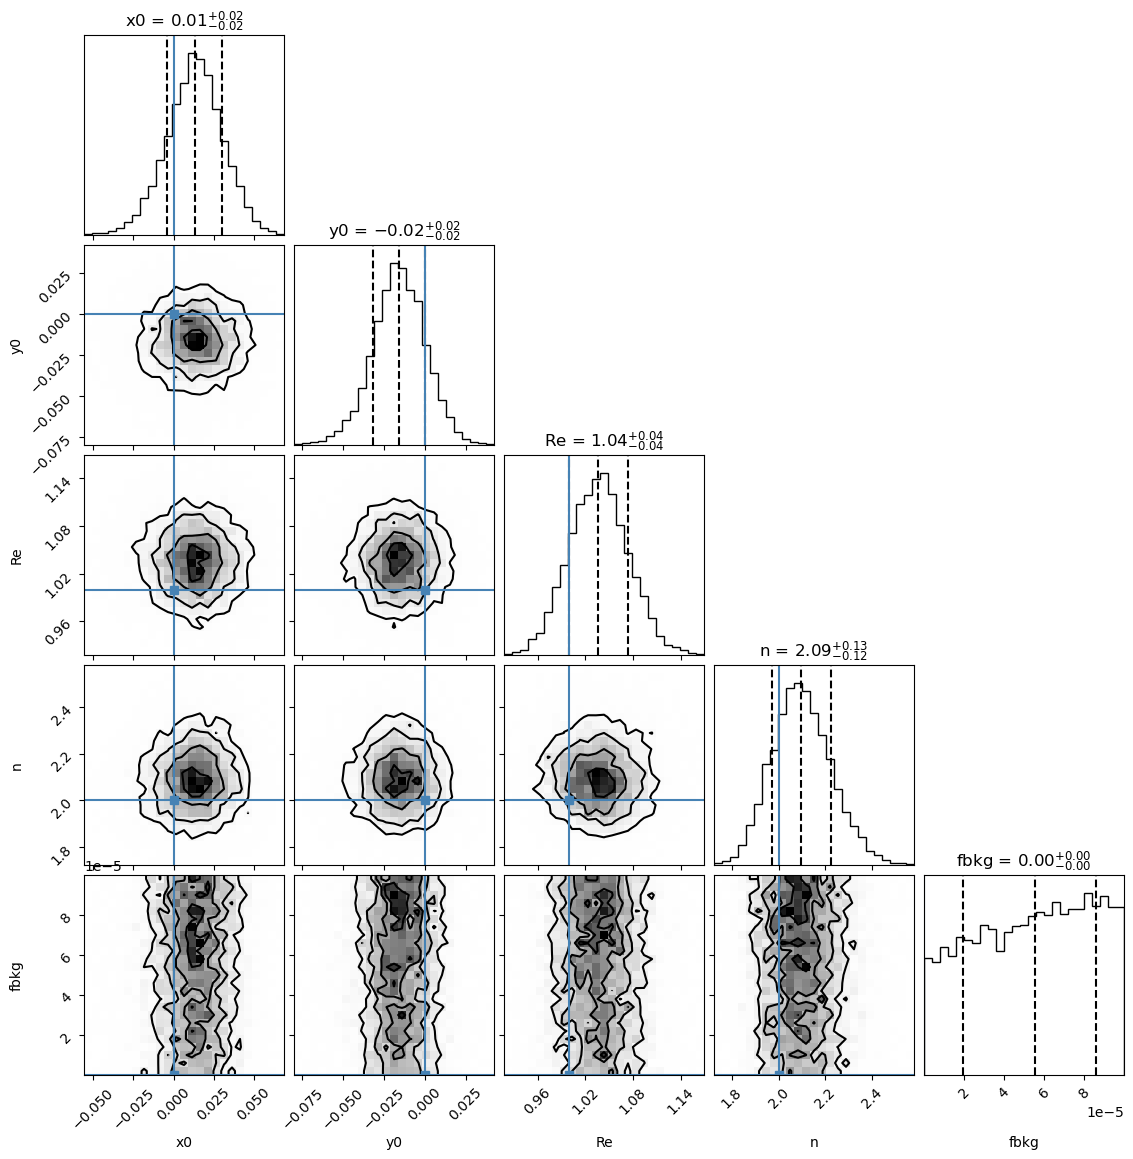

In [ ]:
x, y, nfg = sersic_plus_uniform_circle(1000, fbkg=0, n=2, Re=1, polar_out=False)
datahull = spatial.ConvexHull(np.array((x, y)).T)

prior2 = nautilus.Prior()

prior2.add_parameter('x0', (-2, 2))
prior2.add_parameter('y0', (-2, 2))
prior2.add_parameter('Re', (0.1, 2))
prior2.add_parameter('n', (0.5, 4))
prior2.add_parameter('fbkg', (0.0, 0.0001))

sampler = nautilus.Sampler(prior2, loglike, n_live=1000, likelihood_kwargs=dict(datahull=datahull, n_per_segment=1000), pool=12)
t_start = time.time()
sampler.run(verbose=True)
t_end = time.time()
print('Total time: {:.1f}s'.format(t_end - t_start))

points, log_w, log_l = sampler.posterior()
corner.corner(
    points, weights=np.exp(log_w), bins=25, labels=prior.keys,
    plot_datapoints=False, range=np.repeat(0.999, len(prior.keys)), 
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    truths=[0, 0, 1, 2, 0]);

So for some reason it really wants some background to be present.  What's with that?  Some relative  normalization issue?

What if we make a much much bigger area for the bkg? That should make it much easier to measure...

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 29     | 1        | 4        | 33048    | N/A    | 10101 | -5389.31 
Total time: 36.8s


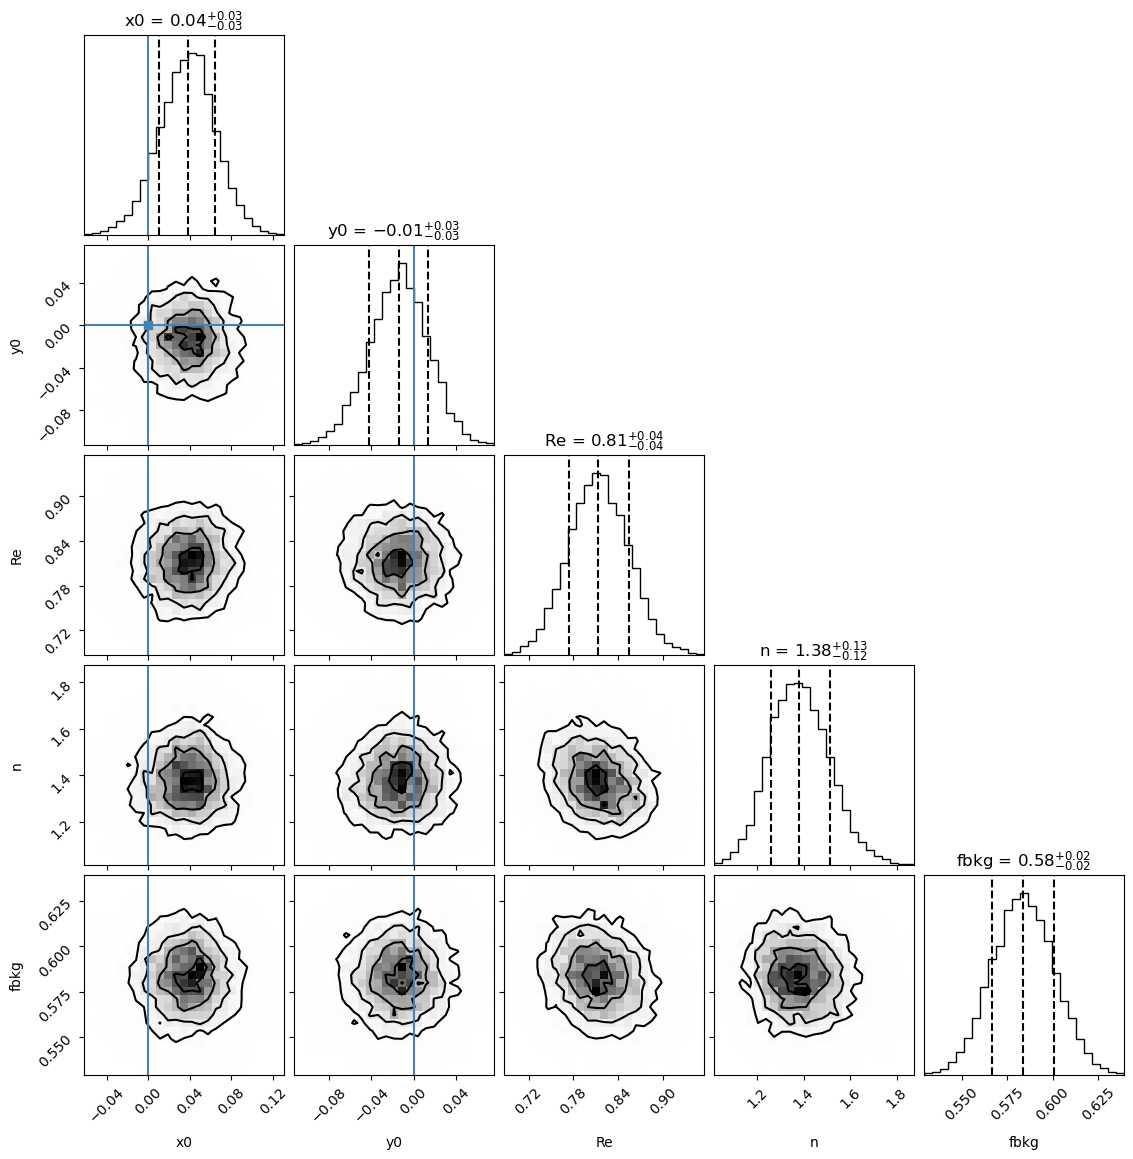

In [ ]:
x, y, nfg = sersic_plus_uniform_circle(1000, fbkg=0.5, n=2, Re=1, polar_out=False, Router=100)
datahull = spatial.ConvexHull(np.array((x, y)).T)

prior2 = nautilus.Prior()

prior2.add_parameter('x0', (-2, 2))
prior2.add_parameter('y0', (-2, 2))
prior2.add_parameter('Re', (0.1, 2))
prior2.add_parameter('n', (0.5, 4))
prior2.add_parameter('fbkg', (0., 1))

sampler = nautilus.Sampler(prior2, loglike, n_live=1000, likelihood_kwargs=dict(datahull=datahull, n_per_segment=1000), pool=12)
t_start = time.time()
sampler.run(verbose=True)
t_end = time.time()
print('Total time: {:.1f}s'.format(t_end - t_start))

points, log_w, log_l = sampler.posterior()
corner.corner(
    points, weights=np.exp(log_w), bins=25, labels=prior.keys,
    plot_datapoints=False, range=np.repeat(0.999, len(prior.keys)), 
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    truths=[0, 0, 1, 2, 0.5]);

Closer to right although not fantastic...

In [ ]:
sersic_integrate_hull(datahull, n_per_segment=10000, n=0.5, Re=1)

np.float64(9.064602307753495)

Wait that can't be right... the integral for a gaussian should be 1!

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 32     | 1        | 8        | 44928    | N/A    | 11801 | +35.78   
Total time: 64.5s


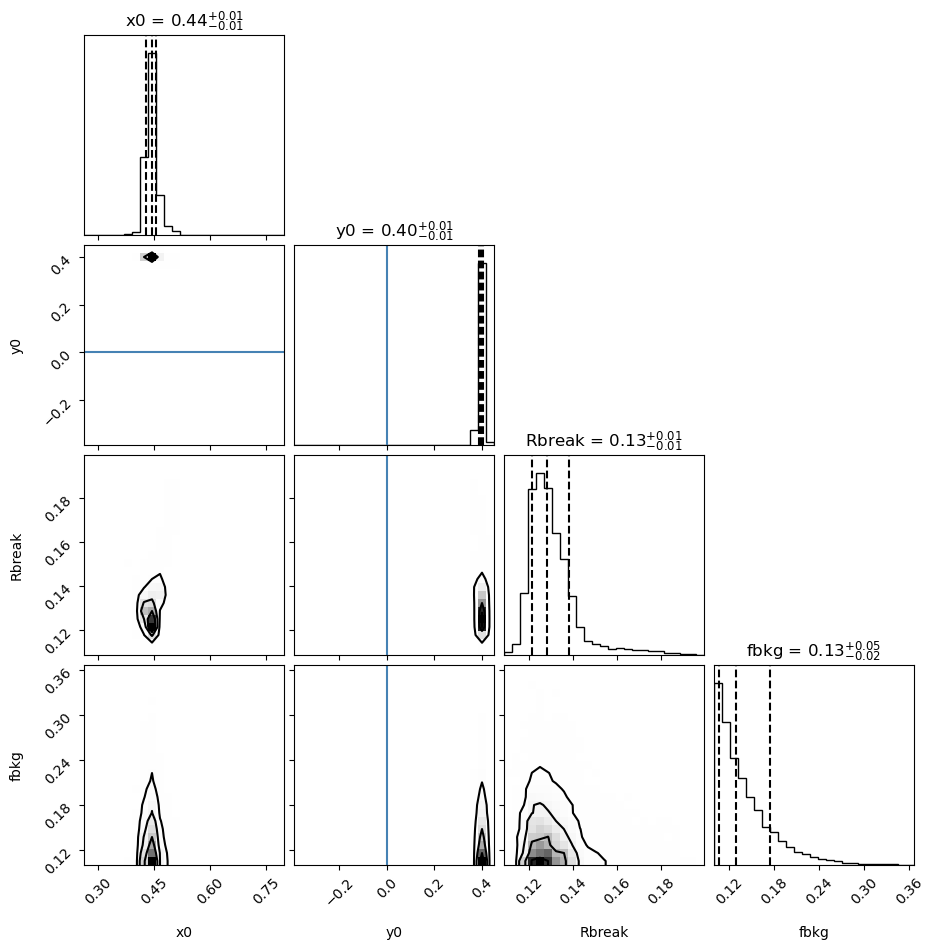

In [ ]:
prior = nautilus.Prior()

prior.add_parameter('x0', (-2, 2))
prior.add_parameter('y0', (-2, 2))
prior.add_parameter('Rbreak', (0.1, 2))
prior.add_parameter('fbkg', (0.1, 0.9))

def loglikes(param_dict, data, n_per_segment=1000):
    x0 = param_dict['x0']
    y0 = param_dict['y0']
    Rbreak = param_dict['Rbreak']
    fbkg = param_dict['fbkg']
    
    r = np.hypot(data[0]-x0, data[1]-y0)

    logfg = np.log(1-fbkg) -  np.log(Rbreak**2*2*np.pi)
    logfg = logfg * (r<Rbreak)

    logbg = np.log(fbkg) -  np.log(np.max(r)**2*2*np.pi)

    return np.logaddexp(logfg, logbg)

def loglike(*args, **kwargs):
    return np.sum(loglikes(*args, **kwargs))


nall = 1000
fbkg = .5
Router = 5
Rbreak = 1

bkgr = np.sqrt(np.random.rand(int(fbkg*nall)))*Router
fgr = np.sqrt(np.random.rand(int((1-fbkg)*nall)))*Rbreak
rall = np.concatenate((fgr, bkgr))
theta = np.random.rand(len(bkgr) + len(fgr))*2*np.pi

x = rall * np.cos(theta)
y = rall * np.sin(theta)

sampler = nautilus.Sampler(prior, loglike, n_live=1000, likelihood_kwargs=dict(data=(x, y)), pool=12)
t_start = time.time()
sampler.run(verbose=True)
t_end = time.time()
print('Total time: {:.1f}s'.format(t_end - t_start))

points, log_w, log_l = sampler.posterior()
corner.corner(
    points, weights=np.exp(log_w), bins=25, labels=prior.keys,
    plot_datapoints=False, range=np.repeat(0.999, len(prior.keys)), 
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    truths=[0, 0, Rbreak, fbkg]);